# Multimodal Cross-Attention Gated Fusion

**Architecture:**
- Text: mDeBERTa-v3-base (full fine-tuning)
- Vision: ALIGN (last N blocks unfrozen)
- EEG: dedicated MLP encoder
- ET: dedicated MLP encoder

Before applying the gates ($ \beta,\alpha,\lambda$), modalities attend to each other bidirectionally. This means:
- Text $\leftrightarrow $ Image: text asks "what visual elements are relevant?" and image asks "what text context matters?"
- Text $\leftrightarrow $ [EEG, ET]: text asks "what cognitive signals are relevant?" and physio asks "what text content triggered this response?"

Then the `enriched` representations are gated (identical to our previous model `03`):
$$z = \text{text}_{\text{enriched}} + \beta \cdot \text{vision}_{\text{attended}} + \alpha \cdot \text{eeg}_{\text{attended}} + \lambda \cdot \text{et}_{\text{attended}}$$

In [1]:
#Libraries
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel, AlignProcessor, AlignModel, get_linear_schedule_with_warmup
warnings.filterwarnings('ignore')

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device  : {torch.cuda.get_device_name(0)}")

# Google Colab or local
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    path = "/content/drive/MyDrive/multimodal-exist"
    os.chdir(path)
    print(f"Loading data from Google Drive: {path}")
else:
    path = "c://Users//diego//Desktop//Master Neuro//M2//Internship_Valencia//multimodal-exist//"
    os.chdir(path)
    print(f"Loading data locally from: {path}")

TEST = False
print(f"TEST MODE: {TEST}")

PyTorch : 2.10.0+cu128
CUDA    : True
Device  : NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from Google Drive: /content/drive/MyDrive/multimodal-exist
TEST MODE: False


In [2]:
#Path
DATA_PATH  = "data/processed/train_model_ready.parquet"
IMG_PATH   = "data/memes/train/memes/"
OUTPUT_DIR = "results/cross_attention_gated"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
#Encoders
TEXT_MODEL_NAME  = "microsoft/mdeberta-v3-base"
ALIGN_MODEL_NAME = "kakaobrain/align-base"

#Vision layers to unfreeze
VISION_UNFREEZE_LAYERS = 2   # last N layers of ALIGN to unfreeze

#CONFIG
MAX_TEXT_LENGTH = 256
COMMON_DIM = 768
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-2
WARMUP_RATIO = 0.1
PATIENCE = 5
N_FOLDS = 3
SEED = 42
VISION_UNFREEZE_BLOCKS = 3

# Cross-Attention CONFIG
N_ATTN_HEADS = 8
GATE_TEMPERATURE = 0.3

if TEST:  # TEST (Quick runs for testing the code, no real training)
    NUM_EPOCHS = 3
    BATCH_SIZE = 8

#Loss Weights for the 3 tasks (sum to 1.0)
LOSS_W21 = 0.40
LOSS_W22 = 0.35
LOSS_W23 = 0.25


#Labels for the 3 tasks
TASK21_COL  = "sexism"
TASK22_COL  = "direct"
TASK23_COLS = [
    "CAT_ideological_inequality",
    "CAT_misogyny_non_sexual_violence",
    "CAT_objectification",
    "CAT_sexual_violence",
    "CAT_stereotyping_dominance"]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nText encoder: {TEXT_MODEL_NAME}")
print(f"Vision encoder: {ALIGN_MODEL_NAME} (unfreeze last {VISION_UNFREEZE_LAYERS} layers)")
print(f"Device: {DEVICE}")
print(f"Folds: {N_FOLDS} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark= False
    os.environ['PYTHONHASHSEED']= str(seed)

set_seed(SEED)
print(f"Seed set: {SEED}")


Text encoder: microsoft/mdeberta-v3-base
Vision encoder: kakaobrain/align-base (unfreeze last 2 layers)
Device: cuda
Folds: 3 | Epochs: 20 | Batch: 16
Seed set: 42


## Read Data

In [4]:
df = pd.read_parquet(DATA_PATH)
if TEST:
    df = df.sample(300, random_state=SEED).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (3984, 208)


,id,lang,text,image_file,split,et_fixation_duration_mean,et_fixation_duration_std,et_fixations_mean,et_fixations_std,et_n_users,...,sexism,task22_valid,direct,task23_valid,task23_num_hard_labels,CAT_ideological_inequality,CAT_misogyny_non_sexual_violence,CAT_objectification,CAT_sexual_violence,CAT_stereotyping_dominance
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,290.553894,46.333007,42.92820,19.900530,2.0,...,1,True,1.0,True,2,0,1,1,0,0
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,272.211591,32.506004,48.00000,25.238859,3.0,...,1,True,1.0,True,2,0,0,0,1,1
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,259.975251,129.980125,40.33335,3.771213,2.0,...,1,True,1.0,True,1,0,0,1,0,0


In [5]:
# We separate EEG and ET columns so we handle them separately in the model.
EEG_COLS = sorted([c for c in df.columns if c.startswith("EEG_") and c not in {"EEG_n_users", "EEG_raw"}])
ET_COLS = sorted([c for c in df.columns if c.startswith("et_") and c not in {"et_n_users"}])
EEG_DIM = len(EEG_COLS)
ET_DIM  = len(ET_COLS)

print(f"\nTask 2.1 distribution:")
print(df[TASK21_COL].value_counts().rename({0:'Non-Sexist', 1:'Sexist'}))
print(f"\nEEG features: {EEG_DIM}")
print(f"ET features: {ET_DIM}")


Task 2.1 distribution:
sexism
Sexist        2617
Non-Sexist    1367
Name: count, dtype: int64

EEG features: 183
ET features: 8


### Data Splits

Full run with n-Fold Stratified CV. Mode Test 80/20 simple split.

In [6]:
#Data Splits
if TEST: # If mode test, no KFold, simple 80/20 split.
    tr_idx, val_idx = train_test_split(np.arange(len(df)),test_size=0.2,random_state=SEED,stratify=df[TASK21_COL])
    folds = [(tr_idx, val_idx)]
    print(f"TEST MODE split: train={len(tr_idx)} | val={len(val_idx)}")

else: # Full run with 5-Fold Stratified CV
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    folds = list(skf.split(df, df[TASK21_COL]))
    print(f"\n5-Fold CV splits (stratified by '{TASK21_COL}'):")
    for i, (tr_idx, val_idx) in enumerate(folds):
        tr_pos  = df.iloc[tr_idx][TASK21_COL].sum()
        val_pos = df.iloc[val_idx][TASK21_COL].sum()
        print(f"  Fold {i+1}: train={len(tr_idx)} ({tr_pos} sexist) | val={len(val_idx)} ({val_pos} sexist)")


5-Fold CV splits (stratified by 'sexism'):
  Fold 1: train=2656 (1744 sexist) | val=1328 (873 sexist)
  Fold 2: train=2656 (1745 sexist) | val=1328 (872 sexist)
  Fold 3: train=2656 (1745 sexist) | val=1328 (872 sexist)


## Dataset Class

Returns `eeg` and `et` as separate tensors so the model can gate them independently.

In [7]:
class Multimodal_Dataset(Dataset):
    def __init__(self, df, img_dir, tokenizer, image_processor, eeg_cols, et_cols, max_length=256):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.eeg_cols = eeg_cols
        self.et_cols = et_cols
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text_enc = self.tokenizer(str(row['text']), max_length=self.max_length,
                                  padding='max_length', truncation=True, return_tensors='pt')

        img_path = os.path.join(self.img_dir, str(row['image_file']))
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))
        img_enc = self.image_processor(images=image, return_tensors='pt')

        eeg = torch.tensor(row[self.eeg_cols].values.astype(np.float32), dtype=torch.float32)
        et = torch.tensor(row[self.et_cols].values.astype(np.float32), dtype=torch.float32)

        t21 = int(row[TASK21_COL])
        t22_val = row[TASK22_COL]
        t22 = int(t22_val) if pd.notna(t22_val) else -1

        if t21 == 1:
            t23 = torch.tensor([float(row[c]) if pd.notna(row[c]) else 0.0
                                for c in TASK23_COLS], dtype=torch.float32)
        else:
            t23 = torch.full((len(TASK23_COLS),), -1.0)

        return {
            'input_ids': text_enc['input_ids'].squeeze(0),
            'attention_mask': text_enc['attention_mask'].squeeze(0),
            'pixel_values': img_enc['pixel_values'].squeeze(0),
            'eeg': eeg, 'et': et,
            'task21': torch.tensor(t21, dtype=torch.long),
            'task22': torch.tensor(t22, dtype=torch.long),
            'task23': t23}


def collate_fn(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0].keys()}

## Model Architecture — Cross-Attention Gated Fusion



```
                    ┌──── Cross-Attention ────┐
                    │                         │
Text (768)  ──────►│ Text ↔ Image (bidi)     │──► text_enriched (768)
Image (768) ──────►│                         │──► vision_attended (768)
                    │                         │
Text (768)  ──────►│ Text ↔ [EEG,ET] (bidi)  │──► text_enriched += physio_context
EEG (768)   ──────►│                         │──► eeg_attended (768)
ET (768)    ──────►│                         │──► et_attended (768)
                    └─────────────────────────┘
                                │
                    ┌──── Scalar Gates ───────┐
                    │ β = σ(W·text_enriched)  │
                    │ α = σ(W·text_enriched)  │
                    │ λ = σ(W·text_enriched)  │
                    └─────────────────────────┘
                                │
        z = text_enriched + β·vision_attended + α·eeg_attended + λ·et_attended
                                │
                    fusion_layer → 3 task heads
```

In [8]:
class PhysioMLP(nn.Module):
    def __init__(self, input_dim, common_dim, dropout=0.2):
        super().__init__()
        hidden = common_dim // 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, common_dim),
            nn.LayerNorm(common_dim),
            nn.ReLU(),
            nn.Dropout(dropout))

    def forward(self, x):
        return self.net(x)


class CrossAttentionGatedModel(nn.Module):
    """
    Cross-Attention Gated Fusion.
    
    Adds bidirectional cross-attention between modalities BEFORE the gated sum.
    - Text - Image: bidirectional cross-attention
    - Text - [EEG, ET]: bidirectional cross-attention
    - Gates operate on enriched representations
    """
    def __init__(
        self,
        text_model_name="microsoft/mdeberta-v3-base",
        vision_model_name="kakaobrain/align-base",
        eeg_dim=183,
        et_dim=9,
        num_cat=5,
        common_dim=768,
        n_attn_heads=8,
        dropout=0.1):

        super().__init__()
        self.common_dim = common_dim

        #Text encoder: mDeBERTa v3 base (768-dim [CLS] token)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size #768
        self.text_projection = (nn.Linear(text_dim, common_dim) if text_dim != common_dim else nn.Identity()) #768

        # Vision Encoder (ALIGN)
        align_full = AlignModel.from_pretrained(vision_model_name)
        self.vision_encoder = align_full.vision_model
        vision_dim = align_full.config.vision_config.hidden_dim #640
        self.vision_projection = (nn.Linear(vision_dim, common_dim) if vision_dim != common_dim else nn.Identity()) #768

        
        # EEG Encoder 
        self.eeg_encoder = PhysioMLP(eeg_dim, common_dim, dropout) #768
        
        # ET Encoder
        self.et_encoder  = PhysioMLP(et_dim,  common_dim, dropout) #768

        # CROSS-ATTENTION 

        # Text ↔ Image (bidirectional)
        self.cross_attn_text_to_image = nn.MultiheadAttention(embed_dim=common_dim, num_heads=n_attn_heads,dropout=dropout, batch_first=True)
        self.cross_attn_image_to_text = nn.MultiheadAttention(embed_dim=common_dim, num_heads=n_attn_heads,dropout=dropout, batch_first=True)

        # Text ↔ Physio [EEG, ET] (bidirectional)
        self.cross_attn_text_to_physio = nn.MultiheadAttention(embed_dim=common_dim, num_heads=n_attn_heads,dropout=dropout, batch_first=True)
        self.cross_attn_physio_to_text = nn.MultiheadAttention(embed_dim=common_dim, num_heads=n_attn_heads,dropout=dropout, batch_first=True)

        # LayerNorms for residual connections after cross-attention
        self.ln_text   = nn.LayerNorm(common_dim)
        self.ln_vision = nn.LayerNorm(common_dim)
        self.ln_physio = nn.LayerNorm(common_dim)

        #Gates conditioned on text_embbeding
        self.gate_vision = nn.Linear(common_dim, 1) # β: how much to trust Image given this text
        self.gate_eeg= nn.Linear(common_dim, 1) # α: how much to trust EEG given this text
        self.gate_et= nn.Linear(common_dim, 1) # λ: how much to trust ET  given this text


        # Fusion + Heads
        
        self.fusion_layer = nn.Sequential(
            nn.Linear(common_dim, common_dim),
            nn.LayerNorm(common_dim),
            nn.ReLU(),
            nn.Dropout(dropout))

        self.head_21 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),      # 768 to 384
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, 2))

        self.head_22 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),      # 768 to 384
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, common_dim // 4), # 384 to 192
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 4, 2))

        self.head_23 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),      # 768 to 384
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, common_dim // 4), # 384 to 192
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 4, num_cat))
        


    def encode(self, input_ids, attention_mask, pixel_values, eeg, et):


        #Text
        text_emb = self.text_projection(self.text_encoder(input_ids=input_ids,attention_mask=attention_mask).last_hidden_state[:, 0, :])  # (B, 768)

        #Vision
        vision_emb = self.vision_projection(self.vision_encoder(pixel_values=pixel_values).pooler_output)  # (B, 768)

        #EEG
        eeg_emb = self.eeg_encoder(eeg.float())   # (B, 768)
        
        #ET
        et_emb  = self.et_encoder(et.float())     # (B, 768)


        #Bidirectional Cross-Attention
        
        # All embeddings need seq dim for MultiheadAttention: (B, 768) → (B, 1, 768)
        text_seq   = text_emb.unsqueeze(1)    # (B, 1, 768)
        vision_seq = vision_emb.unsqueeze(1)  # (B, 1, 768)

        # We stack EEG and ET as 2 physio tokens: (B, 2, 768)
        physio_seq = torch.stack([eeg_emb, et_emb], dim=1)  # (B, 2, 768)

        # Text attends to Image
        text_from_image, _ = self.cross_attn_text_to_image(query=text_seq, key=vision_seq, value=vision_seq)  # (B, 1, 768)

        # Image attends to Text
        image_from_text, _ = self.cross_attn_image_to_text(query=vision_seq, key=text_seq, value=text_seq)  # (B, 1, 768)

        # Text attends to Physio
        text_from_physio, _ = self.cross_attn_text_to_physio(query=text_seq, key=physio_seq, value=physio_seq)  # (B, 1, 768)

        # Physio attends to Text
        physio_from_text, _ = self.cross_attn_physio_to_text(query=physio_seq, key=text_seq, value=text_seq)  # (B, 2, 768)

        # Residual connections + LayerNorm 

        # Text enriched by both image and physio context
        text_enriched = self.ln_text(text_emb + text_from_image.squeeze(1) + text_from_physio.squeeze(1))  # (B, 768)

        # Vision enriched by text context
        vision_attended = self.ln_vision(vision_emb + image_from_text.squeeze(1))  # (B, 768)

        # EEG and ET enriched by text context
        eeg_attended = self.ln_physio(eeg_emb + physio_from_text[:, 0, :])  # (B, 768)
        et_attended = self.ln_physio(et_emb + physio_from_text[:, 1, :])  # (B, 768)

        # Gates
        beta    = torch.sigmoid(self.gate_vision(text_enriched) / GATE_TEMPERATURE)
        alpha   = torch.sigmoid(self.gate_eeg(text_enriched)    / GATE_TEMPERATURE)
        lambda_ = torch.sigmoid(self.gate_et(text_enriched)     / GATE_TEMPERATURE)

        # Gated Fusion Enriched
        z = text_enriched + beta * vision_attended + alpha * eeg_attended + lambda_ * et_attended

        fused = self.fusion_layer(z)

        gate_vals = {
            'beta':   beta.mean().item(),
            'alpha':  alpha.mean().item(),
            'lambda': lambda_.mean().item()}

        return fused, gate_vals

    def forward(self, input_ids, attention_mask, pixel_values, eeg, et):
        shared, gate_vals = self.encode(
            input_ids, attention_mask, pixel_values, eeg, et)
        return (
            self.head_21(shared),
            self.head_22(shared),
            self.head_23(shared),
            gate_vals)

## Loss Functions

In [9]:
#We first compute the class weights for Task 2.1 and Task 2.2, which we will use in the loss function to handle class imbalance

def compute_class_weights(df):
    # Task 2.1 Sexism (0 vs 1)
    counts_21 = df['sexism'].value_counts().sort_index()
    total_21  = counts_21.sum()
    w21_0 = total_21 / (2 * counts_21[0])
    w21_1 = total_21 / (2 * counts_21[1])
    weight_21 = torch.tensor([w21_0, w21_1], dtype=torch.float32)

    # Task 2.2  Direct/Judgemental
    sexist_df = df[df['sexism'] == 1]
    counts_22 = sexist_df['direct'].value_counts().sort_index()
    total_22  = counts_22.sum()
    w22_0 = total_22 / (2 * counts_22[0])
    w22_1 = total_22 / (2 * counts_22[1])
    weight_22 = torch.tensor([w22_0, w22_1], dtype=torch.float32)

    print(f"Task 2.1 weights: class 0 (non-sexist): {w21_0:.3f} | class 1 (sexist): {w21_1:.3f}")
    print(f"Task 2.2 weights: class 0 (judgemental): {w22_0:.3f} | class 1 (direct): {w22_1:.3f}")

    return weight_21, weight_22

WEIGHT_21, WEIGHT_22 = compute_class_weights(df)

Task 2.1 weights: class 0 (non-sexist): 1.457 | class 1 (sexist): 0.761
Task 2.2 weights: class 0 (judgemental): 2.138 | class 1 (direct): 0.653


In [10]:
def compute_multitask_loss(logits_21, logits_22, logits_23,
                           labels_21, labels_22, labels_23,
                           weight_21, weight_22,
                           w21=LOSS_W21, w22=LOSS_W22, w23=LOSS_W23):
    """
    - Task 2.1: CrossEntropy (all samples)
    - Task 2.2: CrossEntropy (masked: only sexist, label != -1)
    - Task 2.3: Weighted BCE per label (masked: only sexist, label != -1)
    """

    # Task 2.1
    loss_21 = F.cross_entropy(logits_21, labels_21,weight=weight_21.to(logits_21.device))

    # Task 2.2 (Direct/ Judgemental) — mask non-sexist samples
    mask_22 = labels_22 != -1
    loss_22 = (F.cross_entropy(
                    logits_22[mask_22], labels_22[mask_22],
                    weight=weight_22.to(logits_22.device))
               if mask_22.sum() > 0
               else torch.tensor(0.0, device=logits_22.device))

    # Task 2.3 (Multi-label) — mask non-sexist samples (label == -1)
    mask_23 = (labels_23 != -1).any(dim=1)
    if mask_23.sum() > 0:
        labels_masked = labels_23[mask_23]
        pos_weight = ((labels_masked == 0).sum(0).float() / (labels_masked == 1).sum(0).float().clamp(min=1)).to(logits_23.device)
        pos_weight = pos_weight.clamp(max=5.0)
        loss_23 = F.binary_cross_entropy_with_logits(logits_23[mask_23], labels_masked, pos_weight=pos_weight)
    else:
        loss_23 = torch.tensor(0.0, device=logits_23.device)

    total = w21 * loss_21 + w22 * loss_22 + w23 * loss_23
    return total, loss_21.item(), loss_22.item(), loss_23.item()

## Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    l21_acc = l22_acc = l23_acc = 0.0
    beta_acc = alpha_acc = lambda_acc = 0.0

    for batch in tqdm(loader, desc="  train", leave=False):
        optimizer.zero_grad()
        with autocast(dtype=torch.bfloat16): 
            logits_21, logits_22, logits_23, gate_vals = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['pixel_values'].to(device),
                batch['eeg'].to(device),
                batch['et'].to(device)
            )

            loss, l21, l22, l23 = compute_multitask_loss(
                logits_21, logits_22, logits_23,
                batch['task21'].to(device),
                batch['task22'].to(device),
                batch['task23'].to(device),
                WEIGHT_21, WEIGHT_22)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        l21_acc += l21; l22_acc += l22; l23_acc += l23
        beta_acc += gate_vals['beta']
        alpha_acc += gate_vals['alpha']
        lambda_acc += gate_vals['lambda']

    n = len(loader)
    return {
        'total':total_loss/n,
        'l21':l21_acc/n,
        'l22':l22_acc/n,
        'l23':l23_acc/n,
        'beta':beta_acc/n,   # mean gate for Image
        'alpha':alpha_acc/n,   # mean gate for EEG
        'lambda':lambda_acc/n,   # mean gate for ET
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_21_preds, all_21_probs, all_21_labels = [], [], []
    all_22_preds, all_22_probs, all_22_labels = [], [], []
    all_23_preds, all_23_probs, all_23_labels = [], [], []
    beta_acc = alpha_acc = lambda_acc = 0.0

    for batch in tqdm(loader, desc="  eval", leave=False):
        with autocast(dtype=torch.bfloat16):
            logits_21, logits_22, logits_23, gate_vals = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['pixel_values'].to(device),
                batch['eeg'].to(device),
                batch['et'].to(device))

        # Cast to float for stable metric computation
        logits_21 = logits_21.float()
        logits_22 = logits_22.float()  
        logits_23 = logits_23.float()  

        # Task 2.1
        prob_21 = F.softmax(logits_21, dim=1)[:, 1].cpu().numpy()
        pred_21 = logits_21.argmax(dim=1).cpu().numpy()
        all_21_preds.extend(pred_21)
        all_21_probs.extend(prob_21)
        all_21_labels.extend(batch['task21'].numpy())

        # Task 2.2 — only sexist
        mask_22 = batch['task22'] != -1
        if mask_22.sum() > 0:
            prob_22 = F.softmax(logits_22[mask_22], dim=1)[:, 1].cpu().numpy()
            pred_22 = logits_22[mask_22].argmax(dim=1).cpu().numpy()
            all_22_preds.extend(pred_22)
            all_22_probs.extend(prob_22)
            all_22_labels.extend(batch['task22'][mask_22].numpy())

        # Task 2.3 — only sexist
        mask_23 = (batch['task23'] != -1).any(dim=1)
        if mask_23.sum() > 0:
            prob_23 = torch.sigmoid(logits_23[mask_23]).cpu().numpy()
            pred_23 = (prob_23 >= 0.5).astype(int)
            all_23_probs.extend(prob_23)
            all_23_preds.extend(pred_23)
            all_23_labels.extend(batch['task23'][mask_23].numpy())

        beta_acc   += gate_vals['beta']
        alpha_acc  += gate_vals['alpha']
        lambda_acc += gate_vals['lambda']

    n = len(loader)
    metrics = {}

    # Task 2.1
    metrics['f1_21'] = f1_score(all_21_labels, all_21_preds, average='macro', zero_division=0)
    probs_21_arr = np.array(all_21_probs)
    metrics['auc_21'] = (
        roc_auc_score(all_21_labels, probs_21_arr)
        if not np.isnan(probs_21_arr).any() else 0.0
    )

    # Task 2.2
    if all_22_labels:
        probs_22_arr = np.array(all_22_probs)
        metrics['f1_22']  = f1_score(all_22_labels, all_22_preds, average='macro', zero_division=0)
        metrics['auc_22'] = (
            roc_auc_score(all_22_labels, probs_22_arr)
            if not np.isnan(probs_22_arr).any() and len(set(all_22_labels)) > 1
            else 0.5
        )
    else:
        metrics['f1_22'] = metrics['auc_22'] = 0.0

    # Task 2.3
    if all_23_labels:
        labels_23_arr = np.array(all_23_labels)
        probs_23_arr  = np.array(all_23_probs)
        preds_23_arr  = np.array(all_23_preds)
        metrics['f1_23'] = f1_score(labels_23_arr, preds_23_arr, average='macro', zero_division=0)
        aucs = [
            roc_auc_score(labels_23_arr[:, i], probs_23_arr[:, i])
            for i in range(labels_23_arr.shape[1])
            if len(set(labels_23_arr[:, i])) > 1 and not np.isnan(probs_23_arr[:, i]).any()
        ]
        metrics['auc_23'] = np.mean(aucs) if aucs else 0.5
    else:
        metrics['f1_23'] = metrics['auc_23'] = 0.0

    # Gate values (interpretability)
    metrics['beta']   = beta_acc/n   # mean β (Image gate)
    metrics['alpha']  = alpha_acc/n   # mean α (EEG gate)
    metrics['lambda'] = lambda_acc/n   # mean λ (ET gate)

    return metrics

## Initialize Tokenizer & Processor

In [12]:
print("Loading tokenizer and processors...")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
align_processor = AlignProcessor.from_pretrained(ALIGN_MODEL_NAME)
print(f"Tokenizer: {TEXT_MODEL_NAME}")
print(f"Processor: {ALIGN_MODEL_NAME}")

Loading tokenizer and processors...


The image processor of type `EfficientNetImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Tokenizer: microsoft/mdeberta-v3-base
Processor: kakaobrain/align-base


## Training Loop

In [13]:
fold_results = []
fold_histories = {}

if TEST:
    print("TEST MODE — frozen encoders, 1 fold, 3 epochs, 300 samples")
else:
    print(f"FULL RUN — {TEXT_MODEL_NAME.split('/')[-1]} + ALIGN + CrossAttn + Gated(EEG, ET)")

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{len(folds)}")
    print(f"{'='*70}")

    set_seed(SEED + fold_idx)

    df_tr  = df.iloc[train_idx].reset_index(drop=True)
    df_val = df.iloc[val_idx].reset_index(drop=True)

    #Datasets and Loaders
    train_ds = Multimodal_Dataset(df_tr,  IMG_PATH, tokenizer, align_processor,
                                  EEG_COLS, ET_COLS, MAX_TEXT_LENGTH)
    val_ds = Multimodal_Dataset(df_val, IMG_PATH, tokenizer, align_processor,
                                EEG_COLS, ET_COLS, MAX_TEXT_LENGTH)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=4, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            collate_fn=collate_fn, num_workers=4, persistent_workers=True)

    # Cross Attention Gated model
    model = CrossAttentionGatedModel(
        text_model_name=TEXT_MODEL_NAME,
        vision_model_name=ALIGN_MODEL_NAME,
        eeg_dim=EEG_DIM,
        et_dim=ET_DIM,
        n_attn_heads=N_ATTN_HEADS,
        common_dim=COMMON_DIM).to(DEVICE).float()

     # We freeze encoders to make it faster and test the fusion and task heads.
    if TEST:
        # Text Encoder Frozen
        for param in model.text_encoder.parameters():
            param.requires_grad = False
        # Vision Encoder Frozen
        for param in model.vision_encoder.parameters():
            param.requires_grad = False

        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        print("Encoders: fully frozen (TEST mode)")
    else:

        #Vision
        for param in model.vision_encoder.parameters():
            param.requires_grad = False
        all_blocks = list(model.vision_encoder.encoder.blocks.children())
        for block in all_blocks[-VISION_UNFREEZE_BLOCKS:]:
            for param in block.parameters():
                param.requires_grad = True

        n_vis_train = sum(p.numel() for p in model.vision_encoder.parameters() if p.requires_grad)
        n_vis_total = sum(p.numel() for p in model.vision_encoder.parameters())
        print(f"  Vision encoder: last {VISION_UNFREEZE_BLOCKS} blocks unfrozen "
              f"({n_vis_train:,} / {n_vis_total:,} = {100*n_vis_train/n_vis_total:.1f}%)")

        #Text
        for param in model.text_encoder.parameters():
            param.requires_grad = True
        n_text = sum(p.numel() for p in model.text_encoder.parameters())
        print(f"  Text encoder  : full fine-tuning ({n_text:,} params)")

        # Count cross-attention params
        n_xattn = sum(p.numel() for n, p in model.named_parameters()
                      if 'cross_attn' in n or 'ln_' in n)
        print(f"  Cross-Attention: {n_xattn:,} params")

        vision_unfrozen = [p for p in model.vision_encoder.parameters() if p.requires_grad]
        other_params = [p for p in model.parameters()
                        if p.requires_grad and not any(p is vp for vp in vision_unfrozen)]

        optimizer = torch.optim.AdamW([
            {'params': other_params, 'lr': LEARNING_RATE},
            {'params': vision_unfrozen, 'lr': LEARNING_RATE * 0.1}
        ], weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    best_val_f1 = 0.0
    patience_cnt = 0
    src = model.module if isinstance(model, nn.DataParallel) else model
    best_state = copy.deepcopy(src.state_dict())
    history = []

    for epoch in range(NUM_EPOCHS):
        train_losses = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_metrics = evaluate(model, val_loader, DEVICE)

        val_f1 = (val_metrics['f1_21'] * LOSS_W21 +
                  val_metrics['f1_22'] * LOSS_W22 +
                  val_metrics['f1_23'] * LOSS_W23)

        history.append({
            'epoch': epoch + 1,
            'loss': train_losses['total'],
            'l21': train_losses['l21'], 'l22': train_losses['l22'], 'l23': train_losses['l23'],
            'train_beta': train_losses['beta'], 'train_alpha': train_losses['alpha'],
            'train_lambda': train_losses['lambda'],
            'f1_21': val_metrics['f1_21'], 'auc_21': val_metrics['auc_21'],
            'f1_22': val_metrics['f1_22'], 'auc_22': val_metrics['auc_22'],
            'f1_23': val_metrics['f1_23'], 'auc_23': val_metrics['auc_23'],
            'val_beta': val_metrics['beta'], 'val_alpha': val_metrics['alpha'],
            'val_lambda': val_metrics['lambda']})

        print(
            f"  Ep {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Loss: {train_losses['total']:.4f} "
            f"(21:{train_losses['l21']:.3f} 22:{train_losses['l22']:.3f} 23:{train_losses['l23']:.3f}) | "
            f"Val F1: 21={val_metrics['f1_21']:.4f} 22={val_metrics['f1_22']:.4f} 23={val_metrics['f1_23']:.4f} | "
            f"Gates \u03b2={val_metrics['beta']:.3f} \u03b1={val_metrics['alpha']:.3f} \u03bb={val_metrics['lambda']:.3f}",
            end="")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_cnt = 0
            src = model.module if isinstance(model, nn.DataParallel) else model
            best_state = copy.deepcopy(src.state_dict())
            ckpt_path = os.path.join(OUTPUT_DIR, f"fold{fold_idx+1}_best.pt")
            torch.save(best_state, ckpt_path)
            print(" Ok!")
        else:
            patience_cnt += 1
            print(f" (patience {patience_cnt}/{PATIENCE})")
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(best_state)
    final_metrics = evaluate(model, val_loader, DEVICE)

    fold_results.append({
        'fold': fold_idx + 1,
        'f1_21': final_metrics['f1_21'], 'auc_21': final_metrics['auc_21'],
        'f1_22': final_metrics['f1_22'], 'auc_22': final_metrics['auc_22'],
        'f1_23': final_metrics['f1_23'], 'auc_23': final_metrics['auc_23'],
        'beta_image': final_metrics['beta'],
        'alpha_eeg': final_metrics['alpha'],
        'lambda_et': final_metrics['lambda']})
    fold_histories[fold_idx + 1] = pd.DataFrame(history)

    print(f"\n  Fold {fold_idx+1} FINAL | "
          f"F1: 21={final_metrics['f1_21']:.4f} 22={final_metrics['f1_22']:.4f} 23={final_metrics['f1_23']:.4f} | "
          f"AUC: 21={final_metrics['auc_21']:.4f} 22={final_metrics['auc_22']:.4f} 23={final_metrics['auc_23']:.4f}\n"
          f"  Gates \u2192 \u03b2(Image)={final_metrics['beta']:.4f}  "
          f"\u03b1(EEG)={final_metrics['alpha']:.4f}  "
          f"\u03bb(ET)={final_metrics['lambda']:.4f}")

    del model
    torch.cuda.empty_cache()

print("\n" + "*" * 70)
print("All folds completed")
print("*" * 70)

FULL RUN — mdeberta-v3-base + ALIGN + CrossAttn + Gated(EEG, ET)

FOLD 1/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
mask_predictions.dense.bias                | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Loading weights:   0%|          | 0/1394 [00:00<?, ?it/s]

AlignModel LOAD REPORT from: kakaobrain/align-base
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  train:   0%|          | 0/166 [00:00<?, ?it/s]

  eval:   0%|          | 0/83 [00:00<?, ?it/s]

  Ep 20/20 | Loss: 0.4383 (21:0.075 22:0.599 23:0.795) | Val F1: 21=0.6025 22=0.5108 23=0.4058 | Gates β=0.793 α=0.353 λ=0.020 (patience 2/5)


  eval:   0%|          | 0/83 [00:00<?, ?it/s]


  Fold 3 FINAL | F1: 21=0.6037 22=0.5463 23=0.4071 | AUC: 21=0.6641 22=0.5890 23=0.6242
  Gates → β(Image)=0.8015  α(EEG)=0.4091  λ(ET)=0.0214

**********************************************************************
All folds completed
**********************************************************************


## Results Summary

In [14]:
df_results = pd.DataFrame(fold_results)

metric_cols = ['f1_21','auc_21','f1_22','auc_22','f1_23','auc_23',
               'beta_image','alpha_eeg','lambda_et']
df_results[metric_cols] = df_results[metric_cols].round(4)

print(f"RESULTS — CrossAttention Gated: {TEXT_MODEL_NAME.split('/')[-1]} + ALIGN + EEG + ET")
print(df_results.to_string(index=False))

print("\n" + "*" * 80)
print("SUMMARY (mean \u00b1 std across folds):")
print("*" * 80)
for task in ['21', '22', '23']:
    f1_vals  = df_results[f'f1_{task}']
    auc_vals = df_results[f'auc_{task}']
    print(f"  Task 2.{task[-1]}: Macro F1 = {f1_vals.mean():.4f} \u00b1 {f1_vals.std():.4f} | "
          f"AUC = {auc_vals.mean():.4f} \u00b1 {auc_vals.std():.4f}")

print("\n" + "*" * 80)
print("GATE VALUES (mean \u00b1 std across folds):")
print("*" * 80)
for gate, label in [('beta_image','\u03b2 Image'), ('alpha_eeg','\u03b1 EEG'), ('lambda_et','\u03bb ET')]:
    vals = df_results[gate]
    print(f"  {label}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")

results_path = os.path.join(OUTPUT_DIR, "cv_results.csv")
df_results.to_csv(results_path, index=False)
print(f"\nResults saved \u2192 {results_path}")

RESULTS — CrossAttention Gated: mdeberta-v3-base + ALIGN + EEG + ET
 fold  f1_21  auc_21  f1_22  auc_22  f1_23  auc_23  beta_image  alpha_eeg  lambda_et
    1 0.6055  0.6662 0.5382  0.6044 0.4083  0.6121      0.9958     0.7366     0.0389
    2 0.6245  0.6680 0.5261  0.5521 0.3770  0.5939      0.3176     0.7981     0.3870
    3 0.6037  0.6641 0.5463  0.5890 0.4071  0.6242      0.8015     0.4091     0.0214

********************************************************************************
SUMMARY (mean ± std across folds):
********************************************************************************
  Task 2.1: Macro F1 = 0.6112 ± 0.0115 | AUC = 0.6661 ± 0.0020
  Task 2.2: Macro F1 = 0.5369 ± 0.0102 | AUC = 0.5818 ± 0.0269
  Task 2.3: Macro F1 = 0.3975 ± 0.0177 | AUC = 0.6101 ± 0.0153

********************************************************************************
GATE VALUES (mean ± std across folds):
********************************************************************************
  β

## Visualizations

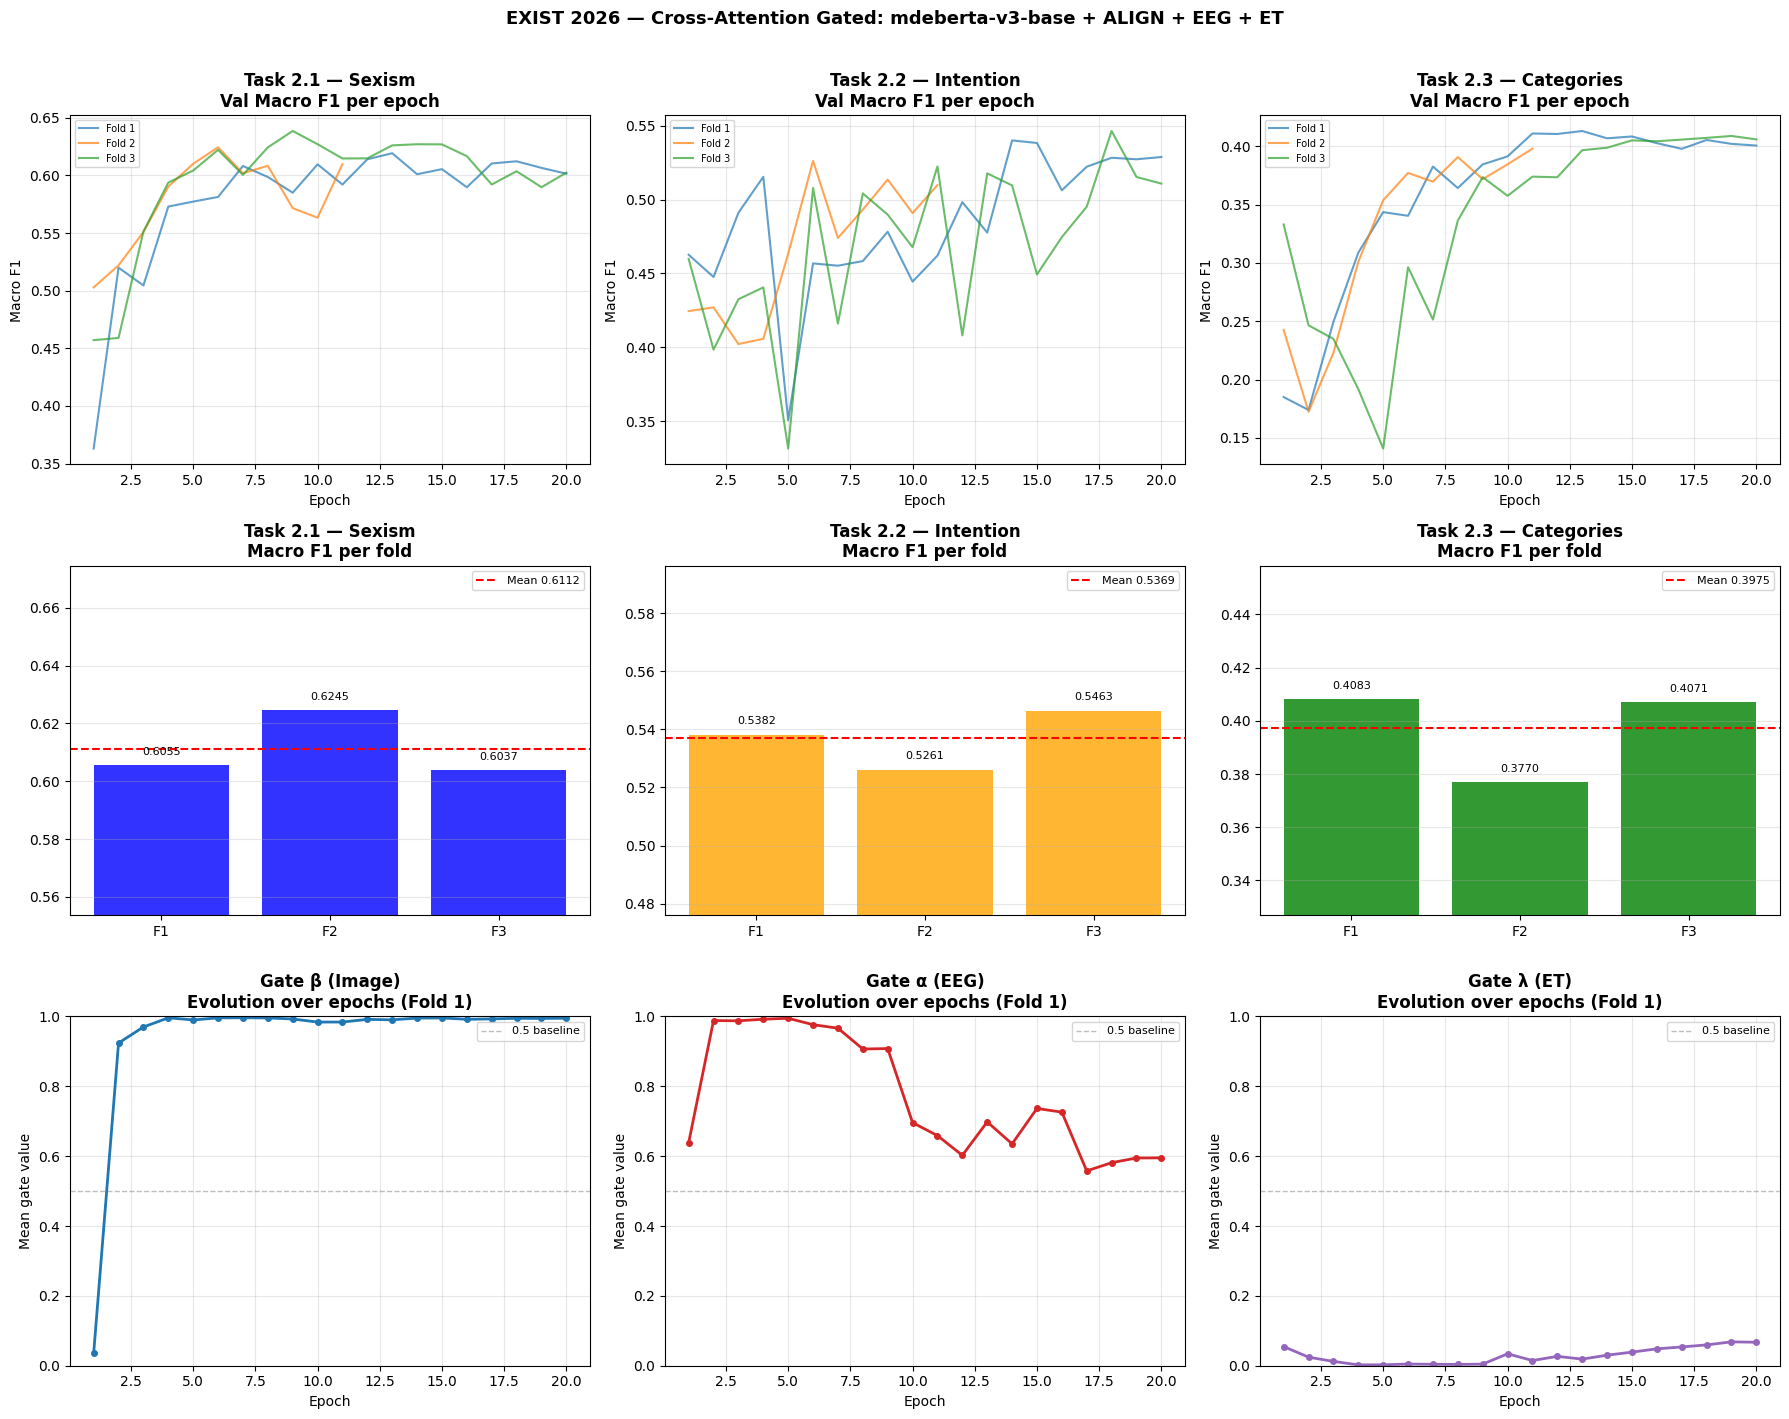

Plot saved in results/cross_attention_gated/cv_results_mdeberta-v3-base.png


In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

tasks  = ['21', '22', '23']
labels = ['Task 2.1 \u2014 Sexism', 'Task 2.2 \u2014 Intention', 'Task 2.3 \u2014 Categories']
colors = ['blue', 'orange', 'green']

for col, (task, label, color) in enumerate(zip(tasks, labels, colors)):
    ax = axes[0, col]
    for fold_n, hist_df in fold_histories.items():
        ax.plot(hist_df['epoch'], hist_df[f'f1_{task}'],
                alpha=0.7, linewidth=1.5, label=f'Fold {fold_n}')
    ax.set_title(f'{label}\nVal Macro F1 per epoch', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[1, col]
    vals = df_results[f'f1_{task}']
    bars = ax.bar([f'F{i}' for i in range(1, len(folds)+1)], vals, color=color, alpha=0.8)
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean {vals.mean():.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{label}\nMacro F1 per fold', fontweight='bold')
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.05))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

if 1 in fold_histories:
    hist1 = fold_histories[1]
    gate_cols = [
        ('val_beta', '\u03b2 (Image)', '#1f77b4'),
        ('val_alpha', '\u03b1 (EEG)', '#d62728'),
        ('val_lambda', '\u03bb (ET)', '#9467bd')]
    for col, (gcol, glabel, gcolor) in enumerate(gate_cols):
        ax = axes[2, col]
        if gcol in hist1.columns:
            ax.plot(hist1['epoch'], hist1[gcol],
                    color=gcolor, linewidth=2, marker='o', markersize=4)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='0.5 baseline')
        ax.set_title(f'Gate {glabel}\nEvolution over epochs (Fold 1)', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Mean gate value')
        ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=0.3)

model_tag = TEXT_MODEL_NAME.split('/')[-1]
plt.suptitle(f'EXIST 2026 \u2014 Cross-Attention Gated: {model_tag} + ALIGN + EEG + ET',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, f'cv_results_{model_tag}.png')
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Plot saved in {plot_path}")

In [16]:
print(f"Model: {TEXT_MODEL_NAME} + ALIGN + CrossAttention + Gated(EEG, ET)")
print(f"Evaluation: {len(folds)}-fold stratified CV on TRAIN\n")
for task, tname in [('21','Sexism Detection'),
                     ('22','Source Intention'),
                     ('23','Sexism Categorization')]:
    f1  = df_results[f'f1_{task}']
    auc = df_results[f'auc_{task}']
    print(f"  Task 2.{task[-1]} ({tname}):")
    print(f"    Macro F1 = {f1.mean():.4f} \u00b1 {f1.std():.4f}")
    print(f"    AUC      = {auc.mean():.4f} \u00b1 {auc.std():.4f}")

print("\nGate values (mean across folds):")
print(f"  \u03b2 (Image) = {df_results['beta_image'].mean():.4f} \u00b1 {df_results['beta_image'].std():.4f}")
print(f"  \u03b1 (EEG)   = {df_results['alpha_eeg'].mean():.4f} \u00b1 {df_results['alpha_eeg'].std():.4f}")
print(f"  \u03bb (ET)    = {df_results['lambda_et'].mean():.4f} \u00b1 {df_results['lambda_et'].std():.4f}")

Model: microsoft/mdeberta-v3-base + ALIGN + CrossAttention + Gated(EEG, ET)
Evaluation: 3-fold stratified CV on TRAIN

  Task 2.1 (Sexism Detection):
    Macro F1 = 0.6112 ± 0.0115
    AUC      = 0.6661 ± 0.0020
  Task 2.2 (Source Intention):
    Macro F1 = 0.5369 ± 0.0102
    AUC      = 0.5818 ± 0.0269
  Task 2.3 (Sexism Categorization):
    Macro F1 = 0.3975 ± 0.0177
    AUC      = 0.6101 ± 0.0153

Gate values (mean across folds):
  β (Image) = 0.7050 ± 0.3493
  α (EEG)   = 0.6479 ± 0.2091
  λ (ET)    = 0.1491 ± 0.2062
